In [1]:
import pandas as pd
import tensorflow as tf
import tensorflow_privacy as tfp
import dp_accounting
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.models import Model
import numpy as np
import time
import gc
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score
import copy
import pickle
import os

c:\Users\slava\OneDrive\Рабочий стол\PyDissertation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
def calculate_permutation_importance(model, X_dict, y_true, feature_names):
    # Считаем базовый AUC
    preds = model.predict(X_dict, verbose=0)
    baseline_auc = roc_auc_score(y_true, preds)
    importances = []

    print(f"Базовый AUC: {baseline_auc:.4f}")
    
    # Проходим по числовым признакам
    for i, col in enumerate(dense_features):
        X_permuted = copy.deepcopy(X_dict)
        # Перемешиваем конкретную колонку в dense_inputs
        save_col = X_permuted['dense_inputs'][:, i].copy()
        np.random.shuffle(X_permuted['dense_inputs'][:, i])
        
        p_preds = model.predict(X_permuted, verbose=0)
        p_auc = roc_auc_score(y_true, p_preds)
        importances.append(baseline_auc - p_auc)
        print(f"Обработан признак: {col}")

    # Проходим по категориальным признакам
    for col in sparse_features:
        X_permuted = copy.deepcopy(X_dict)
        # Перемешиваем эмбеддинг-вход
        np.random.shuffle(X_permuted[col])
        
        p_preds = model.predict(X_permuted, verbose=0)
        p_auc = roc_auc_score(y_true, p_preds)
        importances.append(baseline_auc - p_auc)
        print(f"Обработан признак: {col}")
        
    return importances

In [24]:
# Сделаем замеры для обеих моделей 
sample_size = 300000
X_test_sample = {k: v[:sample_size] for k, v in X_test.items()}
y_test_sample = y_test[:sample_size]

In [25]:
# 1. Базовая модель
print("\n--- Анализ Базовой модели ---")
model_base = build_clean_model(4)
model_base.load_weights('models/baseline_model_dim4.h5')
imp_base = calculate_permutation_importance(model_base, X_test_sample, y_test_sample, all_feature_names)


--- Анализ Базовой модели ---
Базовый AUC: 0.7674
Обработан признак: I1
Обработан признак: I2
Обработан признак: I3
Обработан признак: I4
Обработан признак: I5
Обработан признак: I6
Обработан признак: I7
Обработан признак: I8
Обработан признак: I9
Обработан признак: I10
Обработан признак: I11
Обработан признак: I12
Обработан признак: I13
Обработан признак: C1
Обработан признак: C2
Обработан признак: C3
Обработан признак: C4
Обработан признак: C5
Обработан признак: C6
Обработан признак: C7
Обработан признак: C8
Обработан признак: C9
Обработан признак: C10
Обработан признак: C11
Обработан признак: C12
Обработан признак: C13
Обработан признак: C14
Обработан признак: C15
Обработан признак: C16
Обработан признак: C17
Обработан признак: C18
Обработан признак: C19
Обработан признак: C20
Обработан признак: C21
Обработан признак: C22
Обработан признак: C23
Обработан признак: C24
Обработан признак: C25
Обработан признак: C26


In [26]:
# 2. Приватная модель
print("\n--- Анализ Приватной модели ---")
model_dp = build_clean_model(4)
model_dp.load_weights('models/dp_model_dim4.h5')
imp_dp = calculate_permutation_importance(model_dp, X_test_sample, y_test_sample, all_feature_names)


--- Анализ Приватной модели ---
Базовый AUC: 0.6683
Обработан признак: I1
Обработан признак: I2
Обработан признак: I3
Обработан признак: I4
Обработан признак: I5
Обработан признак: I6
Обработан признак: I7
Обработан признак: I8
Обработан признак: I9
Обработан признак: I10
Обработан признак: I11
Обработан признак: I12
Обработан признак: I13
Обработан признак: C1
Обработан признак: C2
Обработан признак: C3
Обработан признак: C4
Обработан признак: C5
Обработан признак: C6
Обработан признак: C7
Обработан признак: C8
Обработан признак: C9
Обработан признак: C10
Обработан признак: C11
Обработан признак: C12
Обработан признак: C13
Обработан признак: C14
Обработан признак: C15
Обработан признак: C16
Обработан признак: C17
Обработан признак: C18
Обработан признак: C19
Обработан признак: C20
Обработан признак: C21
Обработан признак: C22
Обработан признак: C23
Обработан признак: C24
Обработан признак: C25
Обработан признак: C26


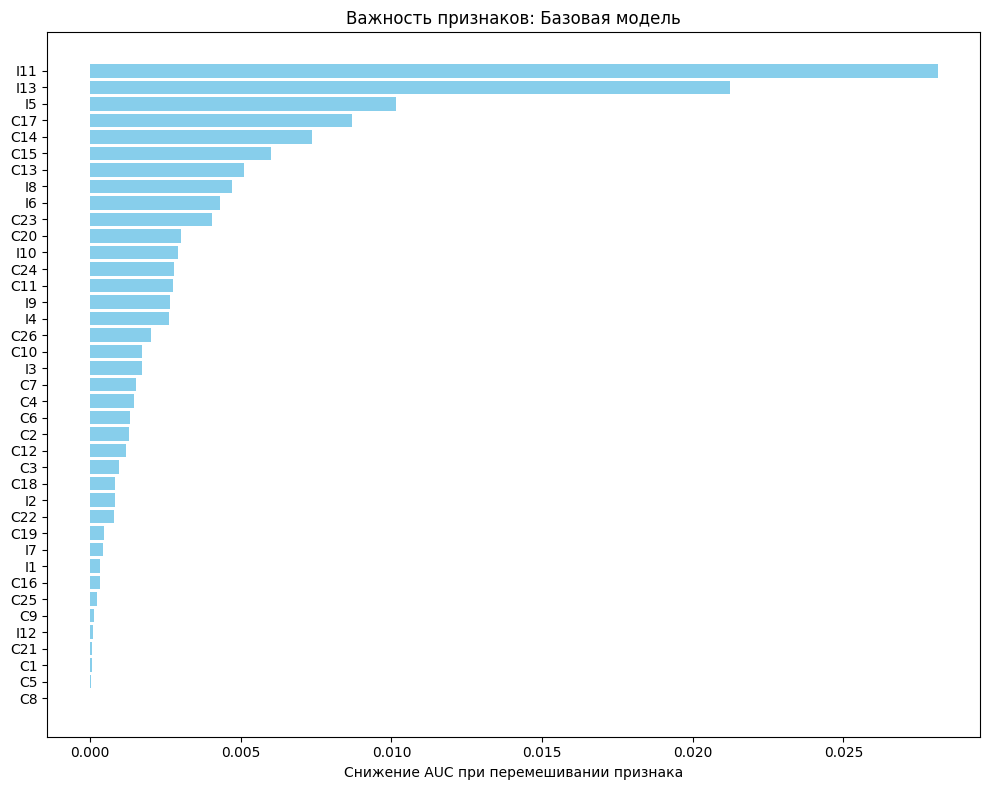

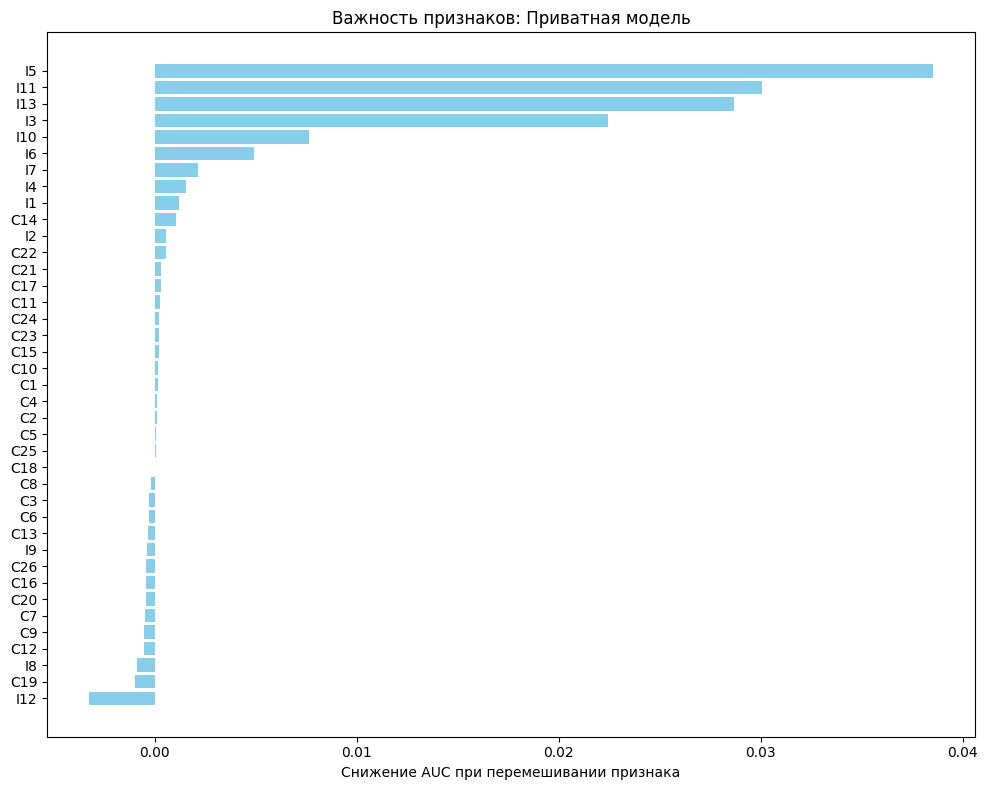

In [27]:
# --- ВИЗУАЛИЗАЦИЯ ---
def plot_imp(imp, title, filename):
    plt.figure(figsize=(10, 8))
    # Сортируем для красоты
    sorted_idx = np.argsort(imp)
    plt.barh(np.array(all_feature_names)[sorted_idx], np.array(imp)[sorted_idx], color='skyblue')
    plt.title(title)
    plt.xlabel("Снижение AUC при перемешивании признака")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_imp(imp_base, "Важность признаков: Базовая модель", "imp_baseline.png")
plot_imp(imp_dp, "Важность признаков: Приватная модель", "imp_dp.png")

In [ ]:
all_feature_names = dense_features + sparse_features

# =====================================================================
# 1. ФУНКЦИЯ РАСЧЕТА И СОХРАНЕНИЯ SHAP
# =====================================================================
def compute_and_save_shap(weights_path, cache_filename, num_explain=3000):
    if os.path.exists(cache_filename):
        print(f"Данные SHAP уже существуют в {cache_filename}. Пропускаем расчет.")
        return

    print(f"Начинаем тяжелый расчет SHAP для {weights_path}...")
    
    # Загрузка модели
    model = build_clean_model(4)
    model.load_weights(weights_path)
    
    # Подготовка данных
    test_arrays = [X_test['dense_inputs']] + [X_test[col] for col in sparse_features]
    X_test_flat = np.column_stack(test_arrays)
    
    X_sample = X_test_flat[:num_explain]
    X_background = shap.sample(X_test_flat, 100)

    # Обертка
    def predict_wrapper(x_flat):
        d_size = len(dense_features)
        inputs = [x_flat[:, :d_size]] 
        for i in range(d_size, x_flat.shape[1]):
            inputs.append(x_flat[:, i:i+1])
        return model.predict(inputs, verbose=0, batch_size=2048).flatten()

    # Расчет
    explainer = shap.KernelExplainer(predict_wrapper, X_background)
    shap_values = explainer.shap_values(X_sample, nsamples=500)
    
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    sv = np.array(sv)

    # СОХРАНЕНИЕ ДАННЫХ В ФАЙЛ
    with open(cache_filename, 'wb') as f:
        pickle.dump({'shap_values': sv, 'X_sample': X_sample}, f)
        
    print(f"💾 Данные успешно сохранены в {cache_filename}!")
    
    del model, explainer
    gc.collect()

In [ ]:
# =====================================================================
# 2. ФУНКЦИИ ОТРИСОВКИ
# =====================================================================

def draw_bar_plot(cache_filename, title, save_name):
    print(f"Рисуем Bar Plot: {title}")
    with open(cache_filename, 'rb') as f:
        data = pickle.load(f)
    sv, X_sample = data['shap_values'], data['X_sample']

    global_importance = np.abs(sv).mean(0).flatten()
    raw_indices = np.argsort(global_importance)[-10:]
    
    features_to_plot = [str(all_feature_names[int(i)]) for i in raw_indices]
    values_to_plot = [float(global_importance[int(i)]) for i in raw_indices]

    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(features_to_plot))
    plt.barh(y_pos, values_to_plot, color='skyblue', edgecolor='navy', alpha=0.8)
    
    plt.yticks(y_pos, features_to_plot)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.xlabel('Mean |SHAP Value| (Влияние признака)', fontsize=12)
    plt.title(f'{title}\nGlobal Feature Importance', fontsize=14, fontweight='bold', pad=15)
    
    max_val = max(values_to_plot) if values_to_plot else 1
    for i, v in enumerate(values_to_plot):
        plt.text(v + (max_val * 0.01), i, f'{v:.5f}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_name, dpi=300)
    plt.show()

In [20]:
def draw_beeswarm_plot(cache_filename, title, save_name):
    print(f"🐝 Рисуем Beeswarm Plot: {title}")
    with open(cache_filename, 'rb') as f:
        data = pickle.load(f)
    sv, X_sample = data['shap_values'], data['X_sample']

    plt.figure(figsize=(10, 10))
    shap.summary_plot(
        sv, X_sample, feature_names=all_feature_names, 
        plot_type="dot", max_display=20, show=False
    )
    plt.title(f"{title}\n(SHAP Beeswarm Plot)", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()


--- 1. РАСЧЕТ И КЭШИРОВАНИЕ SHAP ---
Начинаем тяжелый расчет SHAP для models/baseline_model_dim4.h5...


100%|██████████| 3000/3000 [15:58<00:00,  3.13it/s]


💾 Данные успешно сохранены в shap_data_baseline.pkl!
Начинаем тяжелый расчет SHAP для models/dp_model_dim4.h5...


100%|██████████| 3000/3000 [15:56<00:00,  3.14it/s]


💾 Данные успешно сохранены в shap_data_private.pkl!

--- 2. ГЕНЕРАЦИЯ ГРАФИКОВ (МГНОВЕННО) ---
Рисуем Bar Plot: Baseline Model Interpretation


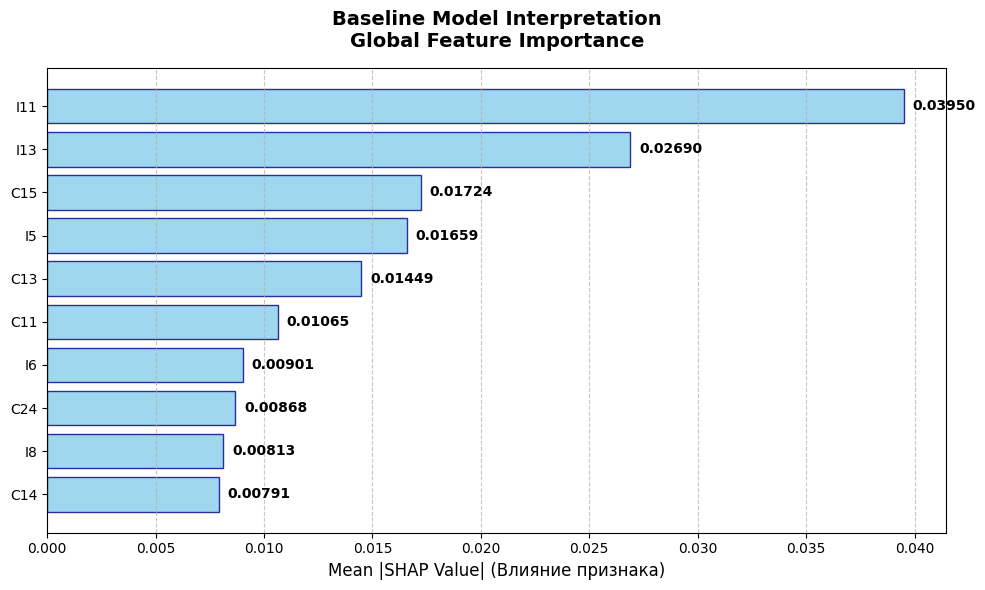

🐝 Рисуем Beeswarm Plot: Логика Базовой Модели


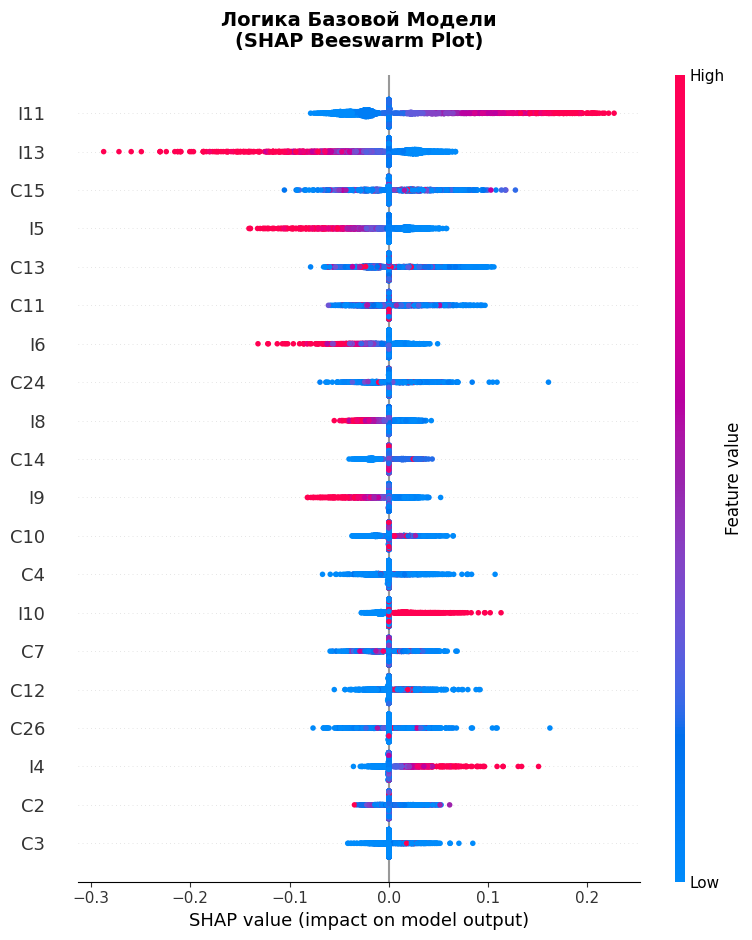

Рисуем Bar Plot: Private Model Interpretation


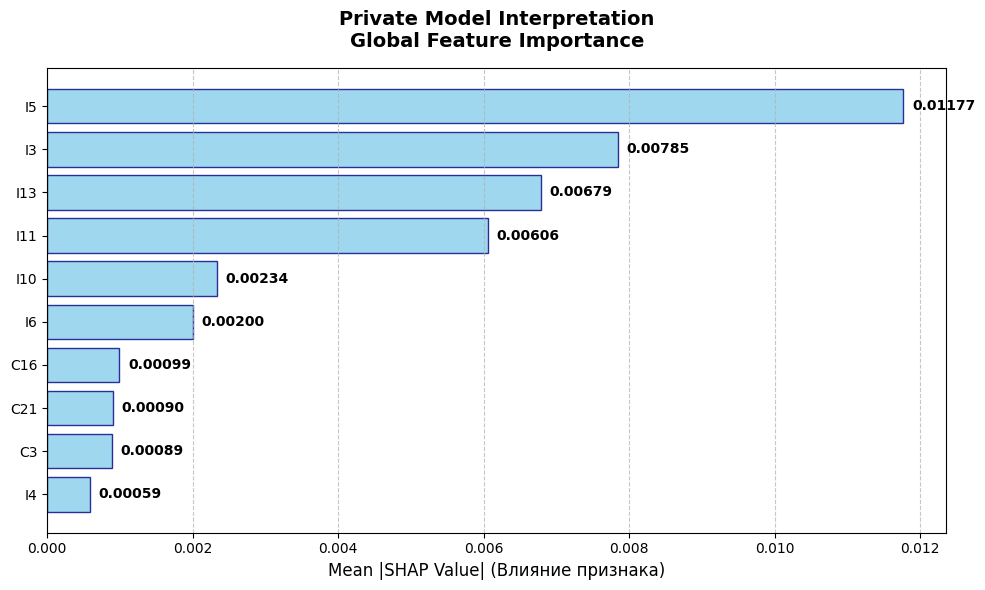

🐝 Рисуем Beeswarm Plot: Логика Приватной Модели (DP-SGD)


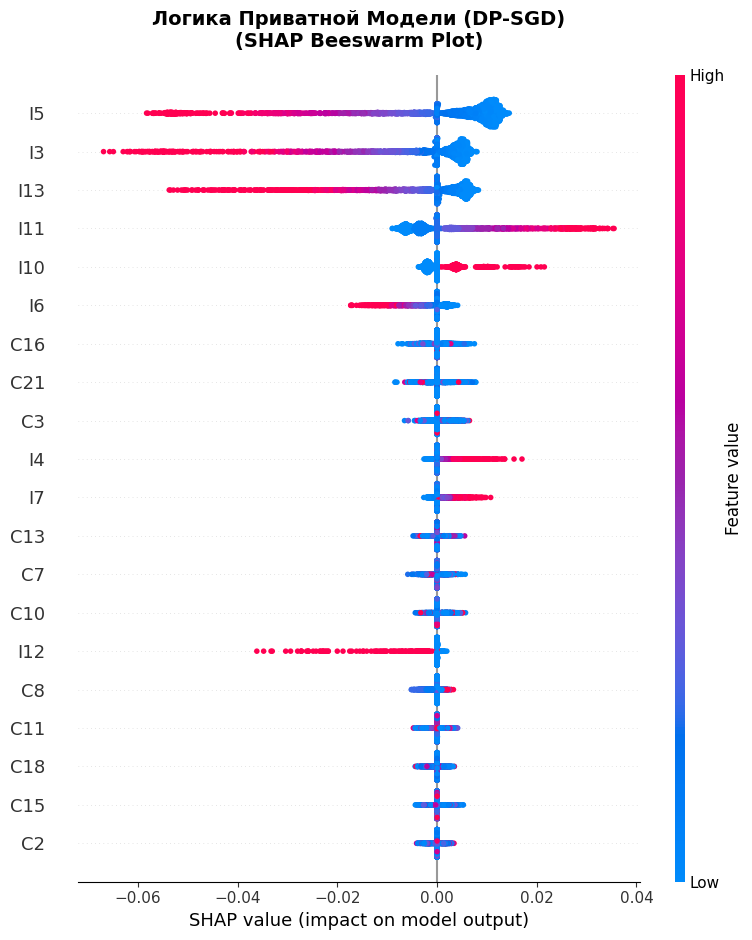

In [21]:
# =====================================================================
# 3. ЗАПУСК ВСЕГО ПРОЦЕССА
# =====================================================================

print("\n--- 1. РАСЧЕТ И КЭШИРОВАНИЕ SHAP ---")
compute_and_save_shap('models/baseline_model_dim4.h5', 'shap_data_baseline.pkl', num_explain=3000)
compute_and_save_shap('models/dp_model_dim4.h5', 'shap_data_private.pkl', num_explain=3000)

print("\n--- 2. ГЕНЕРАЦИЯ ГРАФИКОВ (МГНОВЕННО) ---")
# Базовая модель
draw_bar_plot('shap_data_baseline.pkl', 'Baseline Model Interpretation', 'final_xai_baseline.png')
draw_beeswarm_plot('shap_data_baseline.pkl', 'Логика Базовой Модели', 'beeswarm_baseline.png')

# Приватная модель
draw_bar_plot('shap_data_private.pkl', 'Private Model Interpretation', 'final_xai_private.png')
draw_beeswarm_plot('shap_data_private.pkl', 'Логика Приватной Модели (DP-SGD)', 'beeswarm_private.png')